<a href="https://colab.research.google.com/github/dmorganc14/analisis-alura-store/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [17]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

# Cargar las bases de datos
tienda_1 = pd.read_csv(url)
tienda_2 = pd.read_csv(url2)
tienda_3 = pd.read_csv(url3)
tienda_4 = pd.read_csv(url4)


### Agregar una Columna Identificadora de tienda

In [18]:
tienda_1["tienda"] = "Tienda 1"
tienda_2["tienda"] = "Tienda 2"
tienda_3["tienda"] = "Tienda 3"
tienda_4["tienda"] = "Tienda 4"

### Creando un solo dataframe


In [19]:
datos_tiendas = pd.concat(
    [tienda_1, tienda_2, tienda_3, tienda_4],
    ignore_index=True
)


### Cantidad de registros por tienda

In [20]:
datos_tiendas["tienda"].value_counts()

,count
tienda,
Tienda 1,2359
Tienda 2,2359
Tienda 3,2359
Tienda 4,2358


###Validar columnas y tipos

In [21]:
datos_tiendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  tienda                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


## Unificacion de las tiendas

Con el fin de facilitar el analisis comparativo entre las tiendas de la cadena
Alura Store, se unificaron los datos de las cuatro tiendas en un solo conjunto
de datos.

Para ello, se agrego una columna identificadora que permite reconocer a que
tienda pertenece cada registro. Posteriormente, se concatenaron los datos en
un unico DataFrame, el cual sera utilizado en los analisis posteriores.

In [22]:
datos_tiendas

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Mesa de comedor,Muebles,227700.0,12600.0,12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25184,-75.56359,Tienda 4
9431,Silla de oficina,Muebles,342000.0,18600.0,17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.12539,-73.11980,Tienda 4
9432,Vaso térmico,Deportes y diversión,36700.0,2400.0,03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175,Tienda 4
9433,Set de ollas,Artículos para el hogar,151800.0,8300.0,15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.43722,-76.52250,Tienda 4


## Exploracion inicial de los datos

Antes de realizar analisis detallados, es fundamental comprender la estructura
y el contenido del conjunto de datos. Esta exploracion permite identificar
patrones generales, columnas relevantes y posibles inconsistencias.




## Estructura de los datos

El conjunto de datos contiene informacion relacionada con:

- Producto y categoria: articulos vendidos y su clasificacion.
- Precio y costo de envio: valores asociados a cada venta.
- Fecha y ubicacion de compra: informacion temporal y geografica.
- Calificacion de la compra: evaluaciones realizadas por los clientes.
- Tipo de pago y numero de cuotas: metodos de pago utilizados.
- Coordenadas geograficas: ubicacion de las transacciones.

Explorar y comprender estos datos es el primer paso para realizar
un analisis eficiente y tomar decisiones basadas en informacion confiable.

#1. Análisis de facturación



## Ingreso total por tienda

En este primer analisis se calcula el ingreso total de cada tienda con el fin
de evaluar su desempeno financiero. Para ello, se suman los valores de la
columna `precio` correspondientes a cada tienda.

Este indicador permite identificar que tiendas generan mayores ingresos y
cuales presentan un rendimiento economico inferior.

In [23]:
ingreso_total_por_tienda = (datos_tiendas.groupby("tienda")["Precio"].sum().sort_values(ascending=False))
ingreso_total_por_tienda

,Precio
tienda,
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


# 2. Ventas por categoría

In [24]:
# Ventas por categoría por tienda
ventas_categoria = (
    datos_tiendas
    .groupby(["tienda", "Categoría del Producto"])
    .size()
    .reset_index(name="Cantidad")
)

ventas_categoria

,tienda,Categoría del Producto,Cantidad
0,Tienda 1,Artículos para el hogar,171
1,Tienda 1,Deportes y diversión,284
2,Tienda 1,Electrodomésticos,312
3,Tienda 1,Electrónicos,448
4,Tienda 1,Instrumentos musicales,182
5,Tienda 1,Juguetes,324
6,Tienda 1,Libros,173
7,Tienda 1,Muebles,465
8,Tienda 2,Artículos para el hogar,181
9,Tienda 2,Deportes y diversión,275


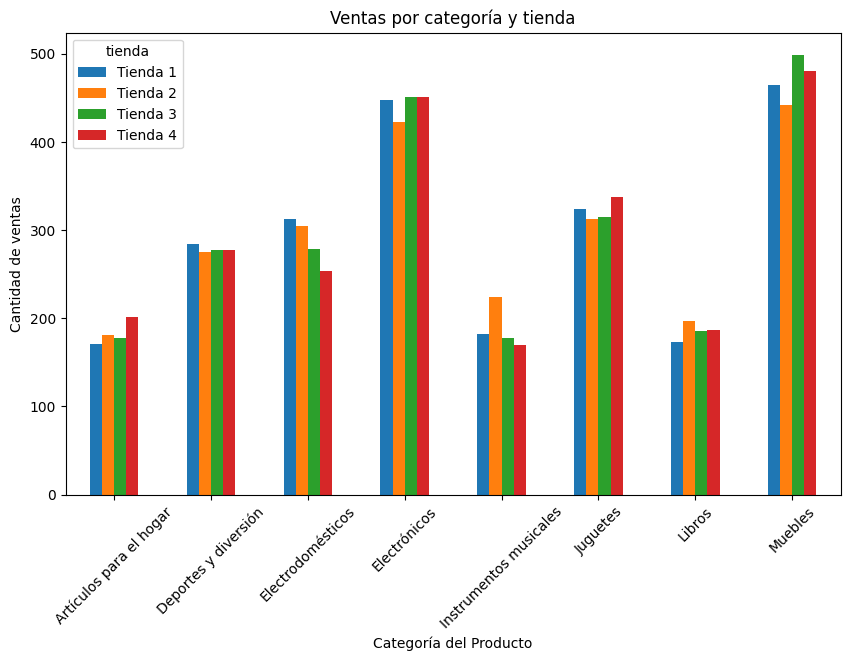

In [25]:
ventas_categoria_pivot = ventas_categoria.pivot(
    index="Categoría del Producto",
    columns="tienda",
    values="Cantidad"
)

ventas_categoria_pivot.plot(kind="bar", figsize=(10,6))

plt.title("Ventas por categoría y tienda")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45)
plt.show()

# 3. Calificación promedio de la tienda


In [26]:
calificacion_promedio = (
    datos_tiendas
    .groupby("tienda")["Calificación"]
    .mean()
    .sort_values(ascending=False)
)

calificacion_promedio

,Calificación
tienda,
Tienda 3,4.048326
Tienda 2,4.037304
Tienda 4,3.995759
Tienda 1,3.976685


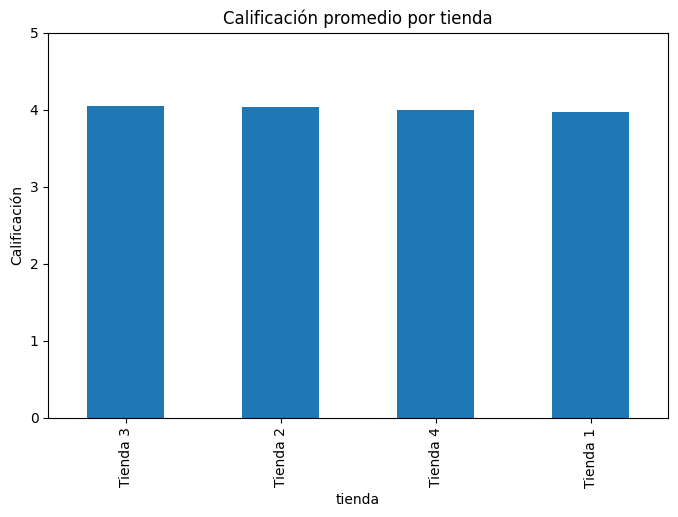

In [27]:
calificacion_promedio.plot(kind="bar", figsize=(8,5))

plt.title("Calificación promedio por tienda")
plt.ylabel("Calificación")
plt.ylim(0,5)
plt.show()

# 4. Productos más y menos vendidos

In [28]:
productos_vendidos = (
    datos_tiendas["Producto"]
    .value_counts()
)

productos_vendidos.head(10)   # más vendidos

,count
Producto,
Mesa de noche,210
Carrito de control remoto,206
Microondas,206
Batería,203
Cama king,201
Secadora de ropa,200
Modelado predictivo,200
Set de ollas,200
Cama box,199


In [29]:
productos_vendidos.tail(10)   # menos vendidos

,count
Producto,
Olla de presión,172
Smartwatch,172
Set de vasos,169
Sillón,168
Asistente virtual,167
Ciencia de datos con Python,166
Guitarra eléctrica,165
Mochila,163
Auriculares con micrófono,158


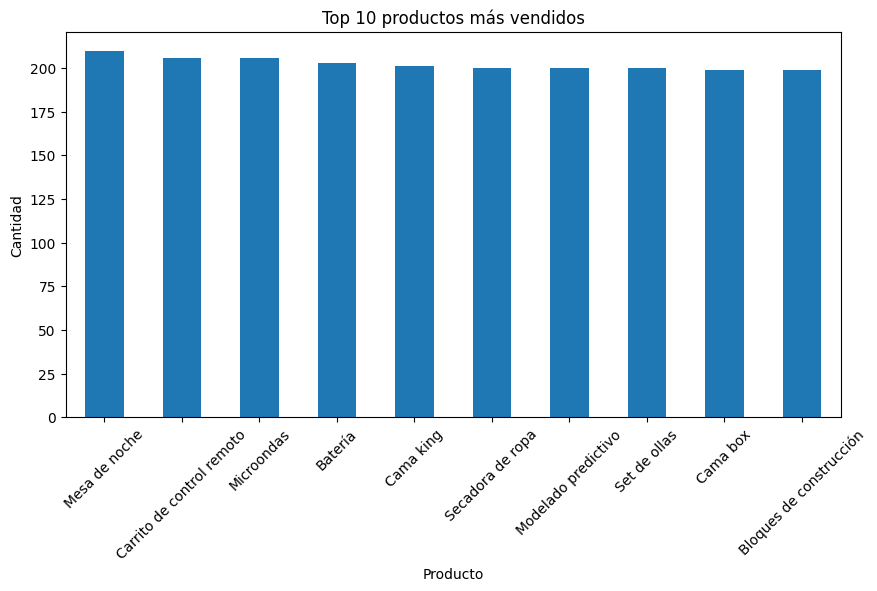

In [30]:
top_productos = productos_vendidos.head(10)

top_productos.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 productos más vendidos")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

# 5. Envío promedio por tienda

In [31]:
envio_promedio = (
    datos_tiendas
    .groupby("tienda")["Costo de envío"]
    .mean()
    .sort_values()
)

envio_promedio

,Costo de envío
tienda,
Tienda 4,23459.457167
Tienda 3,24805.680373
Tienda 2,25216.235693
Tienda 1,26018.609580


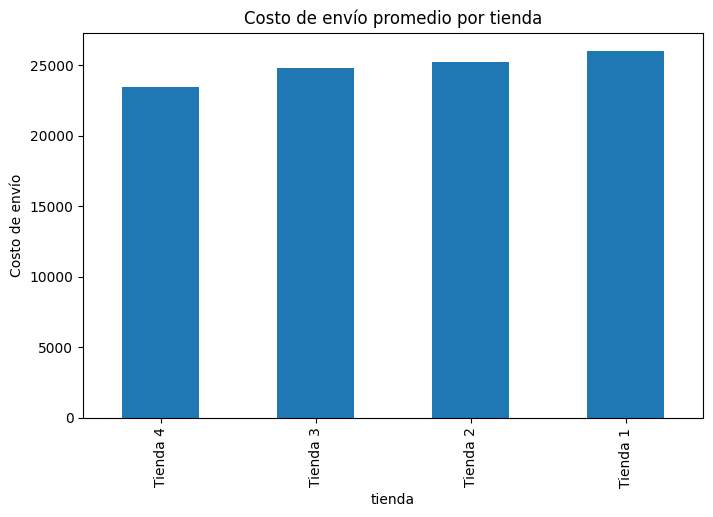

In [32]:
envio_promedio.plot(kind="bar", figsize=(8,5))

plt.title("Costo de envío promedio por tienda")
plt.ylabel("Costo de envío")
plt.show()

# Recomendación final

Después de analizar los datos de las cuatro tiendas de Alura Store, se evaluaron
los siguientes indicadores: ingresos totales, volumen de ventas por categoría,
calificaciones de clientes, productos más vendidos y costos de envío promedio.

La Tienda 1 presenta el mayor ingreso total, lo que indica un buen desempeño
comercial. Sin embargo, la Tienda 4 muestra menores ingresos en comparación con
las demás, además de un rendimiento inferior en algunos indicadores de ventas.

Por otro lado, las calificaciones promedio entre tiendas son similares, lo que
sugiere que la satisfacción del cliente no representa una ventaja competitiva
significativa para la Tienda 4.

Considerando los ingresos más bajos y el menor desempeño general en comparación
con las otras tiendas, se recomienda que el Sr. João venda la Tienda 4, ya que
representa la opción menos rentable dentro del grupo analizado.

Esta decisión permitiría concentrar recursos en las tiendas con mejor desempeño
y mayor potencial de crecimiento.